# Hotel Booking Demand Analysis & Revenue Optimization
*Business Analytics Project | Portfolio Case Study*

## 1. Executive Summary & Project Introduction

### Project Background
In the hospitality industry, managing room availability, pricing, and cancellations is critical to maximizing profitability. Hotel booking cancellations present a significant operational challenge: they create inventory uncertainty, lead to lost revenue opportunities, and disrupt staffing and supply chain planning. 

This project performs a comprehensive Exploratory Data Analysis (EDA) on the **Hotel Booking Demand** dataset, which contains **119,390 observations** representing bookings made between **July 2015 and August 2017** for two distinct hotel types:
1. **City Hotel**: An urban business hotel.
2. **Resort Hotel**: A leisure-oriented vacation resort.

### Business Objectives
The primary objective of this analysis is to identify key operational patterns and booking behaviors that drive cancellations and revenue loss. Specifically, we aim to answer the following core business questions:
- How do cancellation rates compare between urban business hotels and resort hotels?
- What are the peak booking months and seasonal patterns for each hotel type?
- Which customer segments contribute the most bookings, and which are the most reliable?
- How does the Average Daily Rate (ADR) vary seasonally across the different hotels?
- What is the relationship between booking lead time and the likelihood of cancellation?
- Where do our guests originate from, and what are the top target markets?
- Which distribution channels bring in the most volume vs. the highest cancellation rates?
- What is the estimated revenue loss resulting directly from booking cancellations?

By answering these questions, we will formulate data-driven business recommendations to help hotel management minimize cancellation rates and recover lost revenue.

In [1]:
# Imports and Configuration
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Set style for professional portfolio charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

# Disable warnings for cleaner notebook presentation
import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading & Overview
In this section, we load the raw dataset and inspect its structure, dimensions, and schema to understand the fields available for analysis.

In [2]:
# Load the dataset
df = pd.read_csv('hotel_bookings.csv')

# Display basic structural info
print(f"Dataset Dimensions: {df.shape[0]:,} rows, {df.shape[1]} columns\n")
print("Data Schema Overview:")
df.info()

Dataset Dimensions: 119,390 rows, 32 columns

Data Schema Overview:
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies               

In [3]:
# View first 5 rows
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 3. Data Cleaning & Preprocessing
To ensure analytical integrity, we must identify and handle missing values, correct data types, and filter out invalid records.

In [4]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

# Clean missing values:
# 1. Fill missing 'country' with 'Unknown'
df['country'] = df['country'].fillna('Unknown')

# 2. Fill missing 'agent' and 'company' with 0 (indicating direct booking / no company booking)
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

# 3. Handle missing 'children' by dropping the 4 missing rows (insignificant fraction of 119k)
df = df.dropna(subset=['children'])

# Convert data types for consistency:
# Float columns representing IDs or counts are converted to integers
df['children'] = df['children'].astype(int)
df['agent'] = df['agent'].astype(int)
df['company'] = df['company'].astype(int)

# Filter out invalid entries:
# Bookings must have at least one guest (adults + children + babies > 0)
zero_guests_filter = (df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)
print(f"\nDropping {df[zero_guests_filter].shape[0]} rows where total guests are zero.")
df = df[~zero_guests_filter]

print(f"Cleaned Dataset Dimensions: {df.shape[0]:,} rows, {df.shape[1]} columns")

Missing values per column:
children         4
country        488
agent        16340
company     112593
dtype: int64

Dropping 180 rows where total guests are zero.
Cleaned Dataset Dimensions: 119,206 rows, 32 columns


## 4. Exploratory Data Analysis & Visualizations
We perform exploratory analysis and construct visualizations to address our core business questions. We use Seaborn's `'muted'` and `'coolwarm'` color palettes for a consistent, professional visual identity.

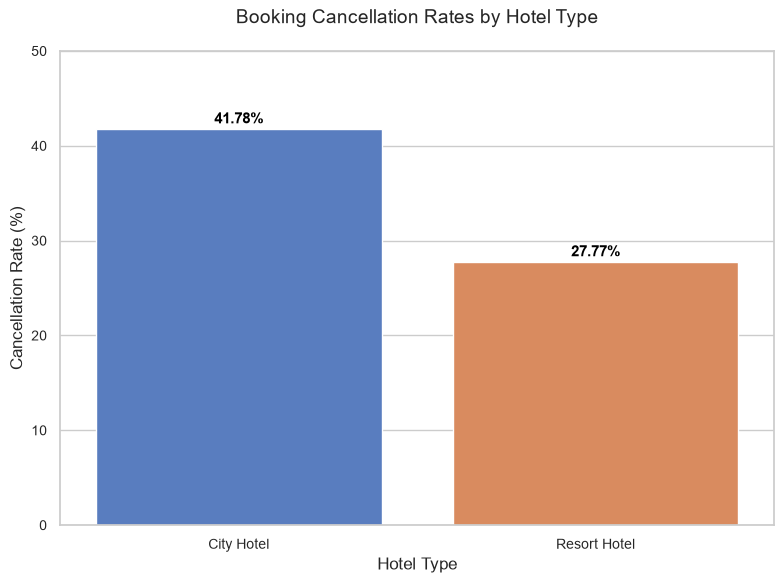

In [5]:
# 1. Cancellation rate comparison: City Hotel vs Resort Hotel
cancellation_rates = df.groupby('hotel')['is_canceled'].mean().reset_index()
cancellation_rates['is_canceled'] *= 100 # Convert to percentage

plt.figure(figsize=(8, 6))
palette = sns.color_palette("muted")
ax = sns.barplot(x='hotel', y='is_canceled', data=cancellation_rates, palette=palette[:2])

plt.title('Booking Cancellation Rates by Hotel Type', pad=20)
plt.xlabel('Hotel Type')
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, 50)

# Annotate bars with values
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height() + 1), 
                ha='center', va='center', fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig('cancellation_by_hotel.png', dpi=300)
plt.show()

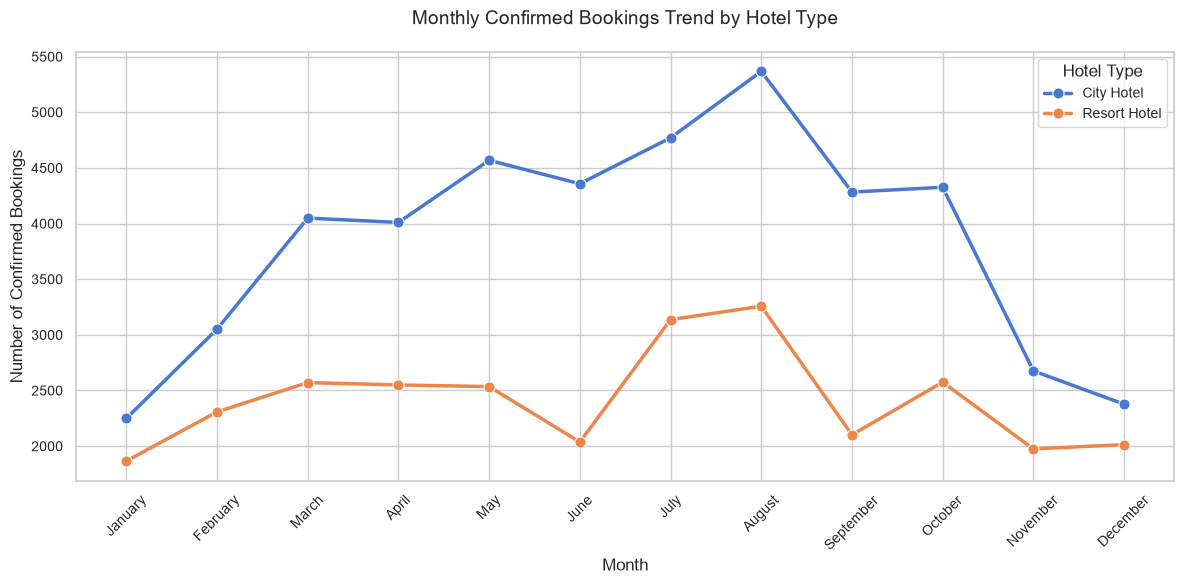

In [6]:
# 2. Monthly booking trends (which months are busiest)
# We filter for active bookings (is_canceled == 0) to understand actual guest stays
active_bookings = df[df['is_canceled'] == 0]

months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']

monthly_bookings = active_bookings.groupby(['arrival_date_month', 'hotel']).size().reset_index(name='bookings')
monthly_bookings['arrival_date_month'] = pd.Categorical(monthly_bookings['arrival_date_month'], categories=months_order, ordered=True)
monthly_bookings = monthly_bookings.sort_values('arrival_date_month')

plt.figure(figsize=(12, 6))
sns.lineplot(x='arrival_date_month', y='bookings', hue='hotel', data=monthly_bookings, 
             marker='o', markersize=8, palette=palette[:2], linewidth=2.5)

plt.title('Monthly Confirmed Bookings Trend by Hotel Type', pad=20)
plt.xlabel('Month')
plt.ylabel('Number of Confirmed Bookings')
plt.xticks(rotation=45)
plt.legend(title='Hotel Type')
plt.tight_layout()
plt.savefig('monthly_booking_trends.png', dpi=300)
plt.show()

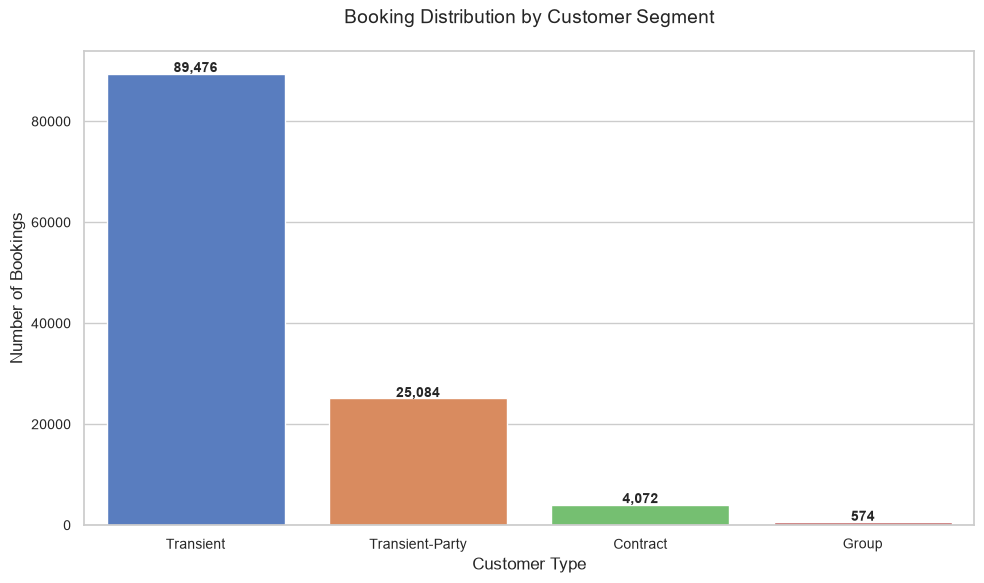

In [7]:
# 3. Customer segments booking volume
customer_counts = df['customer_type'].value_counts().reset_index()
customer_counts.columns = ['customer_type', 'booking_count']

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='customer_type', y='booking_count', data=customer_counts, palette=palette)

plt.title('Booking Distribution by Customer Segment', pad=20)
plt.xlabel('Customer Type')
plt.ylabel('Number of Bookings')

# Annotate counts on bars
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", 
                (p.get_x() + p.get_width() / 2., p.get_height() + 1000), 
                ha='center', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('bookings_by_customer_segment.png', dpi=300)
plt.show()

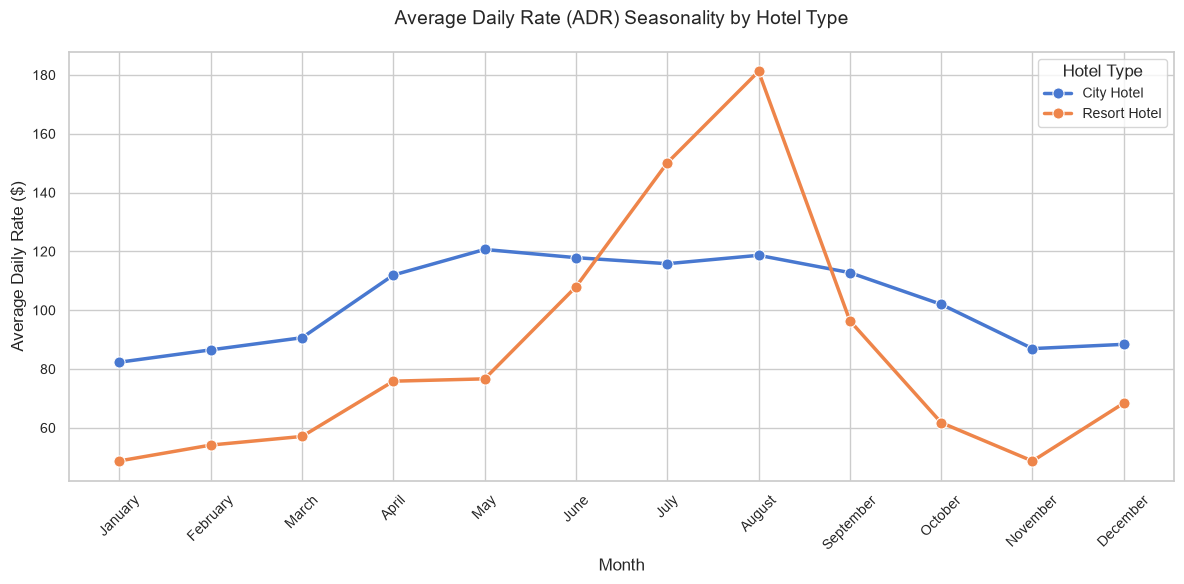

In [8]:
# 4. Average Daily Rate (ADR) by hotel type and month
# We use active bookings and exclude negative ADR and extreme outliers for a clean visual representation
adr_clean = active_bookings[(active_bookings['adr'] >= 0) & (active_bookings['adr'] < 1000)]

monthly_adr = adr_clean.groupby(['arrival_date_month', 'hotel'])['adr'].mean().reset_index()
monthly_adr['arrival_date_month'] = pd.Categorical(monthly_adr['arrival_date_month'], categories=months_order, ordered=True)
monthly_adr = monthly_adr.sort_values('arrival_date_month')

plt.figure(figsize=(12, 6))
sns.lineplot(x='arrival_date_month', y='adr', hue='hotel', data=monthly_adr, 
             marker='o', markersize=8, palette=palette[:2], linewidth=2.5)

plt.title('Average Daily Rate (ADR) Seasonality by Hotel Type', pad=20)
plt.xlabel('Month')
plt.ylabel('Average Daily Rate ($)')
plt.xticks(rotation=45)
plt.legend(title='Hotel Type')
plt.tight_layout()
plt.savefig('adr_seasonality.png', dpi=300)
plt.show()

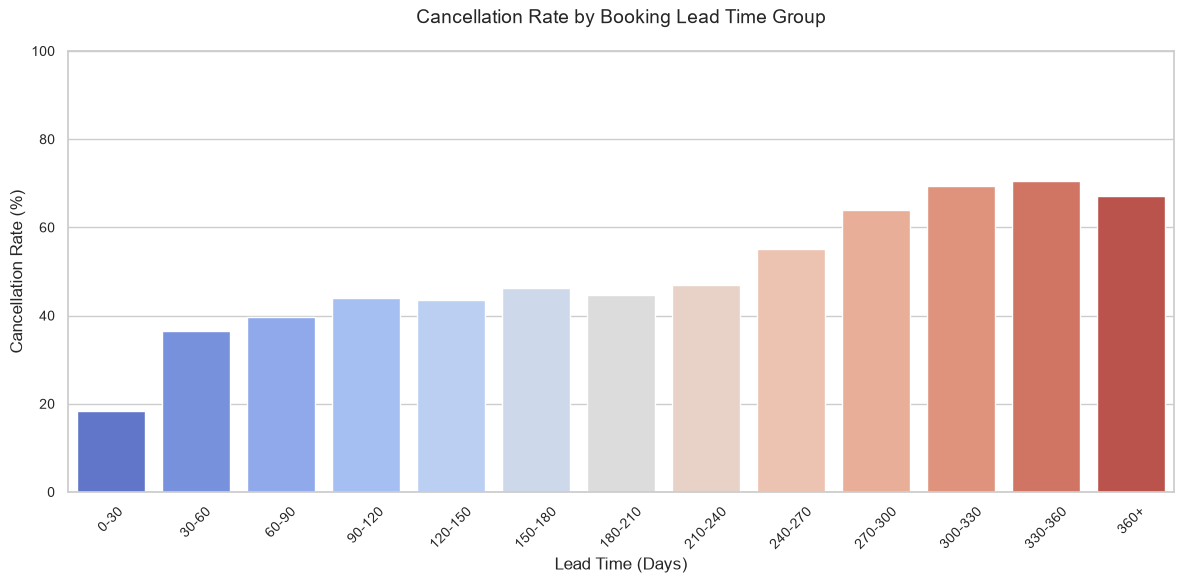

In [9]:
# 5. Lead time vs cancellation rate correlation
# Bin lead times into 30-day intervals up to 360 days, and group anything larger into 360+
def bin_lead_time(lt):
    if lt <= 360:
        lower = (lt // 30) * 30
        upper = lower + 30
        return f"{lower}-{upper}"
    else:
        return "360+"

df['lead_time_group'] = df['lead_time'].apply(bin_lead_time)

# Custom sort order for bins
lead_time_bins = [f"{i}-{i+30}" for i in range(0, 360, 30)] + ["360+"]
df['lead_time_group'] = pd.Categorical(df['lead_time_group'], categories=lead_time_bins, ordered=True)

lead_time_cancel = df.groupby('lead_time_group')['is_canceled'].mean().reset_index()
lead_time_cancel['is_canceled'] *= 100

plt.figure(figsize=(12, 6))
sns.barplot(x='lead_time_group', y='is_canceled', data=lead_time_cancel, palette="coolwarm")

plt.title('Cancellation Rate by Booking Lead Time Group', pad=20)
plt.xlabel('Lead Time (Days)')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('lead_time_vs_cancellation.png', dpi=300)
plt.show()

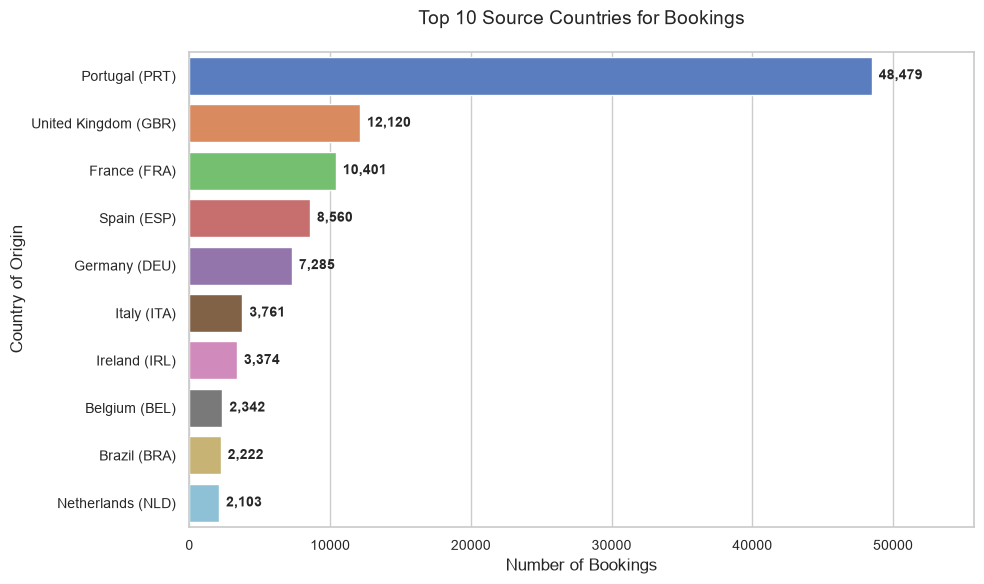

In [10]:
# 6. Top countries by number of bookings
top_countries = df['country'].value_counts().head(10).reset_index()
top_countries.columns = ['country', 'booking_count']

# Map country codes to country names for better readability
country_names = {
    'PRT': 'Portugal (PRT)', 'GBR': 'United Kingdom (GBR)', 'FRA': 'France (FRA)',
    'ESP': 'Spain (ESP)', 'DEU': 'Germany (DEU)', 'ITA': 'Italy (ITA)',
    'IRL': 'Ireland (IRL)', 'BEL': 'Belgium (BEL)', 'BRA': 'Brazil (BRA)',
    'NLD': 'Netherlands (NLD)'
}
top_countries['country_name'] = top_countries['country'].map(country_names).fillna(top_countries['country'])

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='booking_count', y='country_name', data=top_countries, palette='muted')

plt.title('Top 10 Source Countries for Bookings', pad=20)
plt.xlabel('Number of Bookings')
plt.ylabel('Country of Origin')

# Annotate bar values
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{int(width):,}", 
                (width + 500, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=10, fontweight='bold')

plt.xlim(0, max(top_countries['booking_count']) * 1.15)
plt.tight_layout()
plt.savefig('top_countries.png', dpi=300)
plt.show()

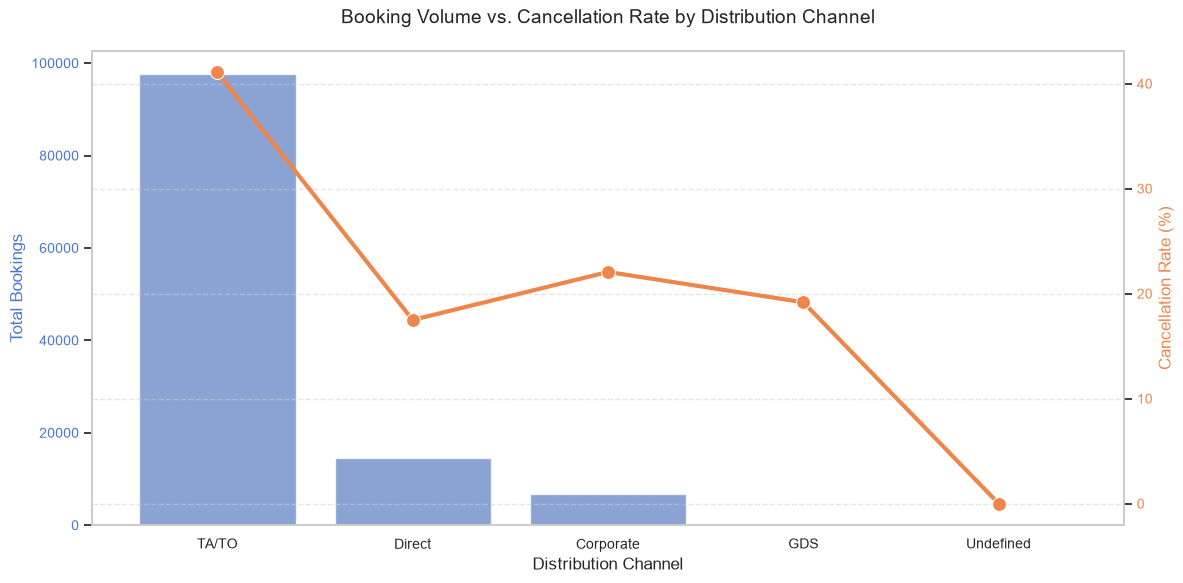

In [11]:
# 7. Distribution channel analysis
channel_stats = df.groupby('distribution_channel').agg(
    total_bookings=('is_canceled', 'count'),
    cancellation_rate=('is_canceled', 'mean')
).reset_index()
channel_stats['cancellation_rate'] *= 100
channel_stats = channel_stats.sort_values('total_bookings', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis: Booking volume
color = palette[0]
sns.barplot(x='distribution_channel', y='total_bookings', data=channel_stats, ax=ax1, color=color, alpha=0.7)
ax1.set_xlabel('Distribution Channel')
ax1.set_ylabel('Total Bookings', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(False)

# Secondary axis: Cancellation rate
ax2 = ax1.twinx()
color = palette[1]
sns.lineplot(x='distribution_channel', y='cancellation_rate', data=channel_stats, ax=ax2, color=color, marker='o', markersize=10, linewidth=3)
ax2.set_ylabel('Cancellation Rate (%)', color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.title('Booking Volume vs. Cancellation Rate by Distribution Channel', pad=20)
plt.tight_layout()
plt.savefig('distribution_channel_analysis.png', dpi=300)
plt.show()

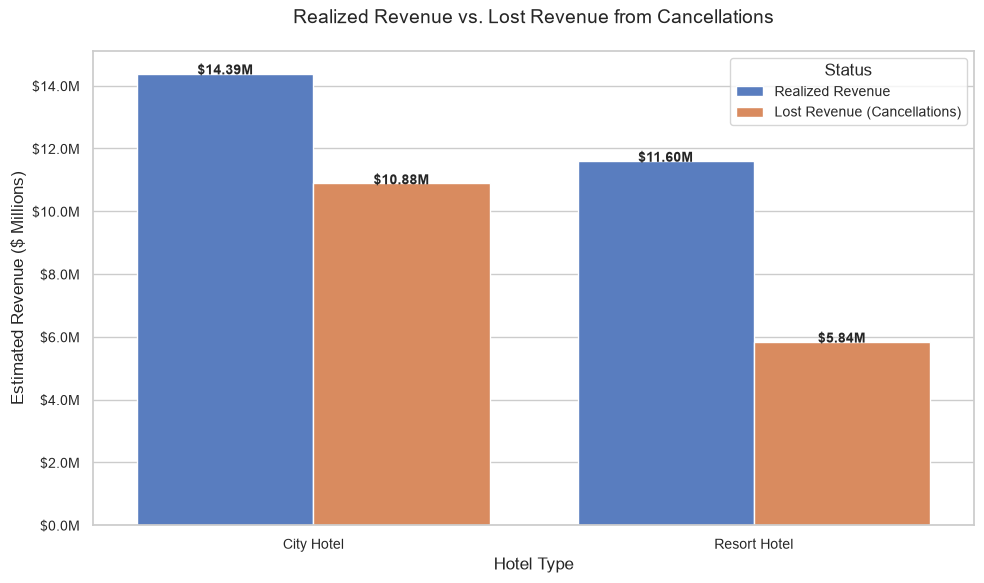

In [12]:
# 8. Revenue loss from cancellations estimate
# Realized Revenue: confirmed bookings revenue = adr * (stays_in_weekend_nights + stays_in_week_nights)
# Lost Revenue: cancelled bookings revenue = adr * (stays_in_weekend_nights + stays_in_week_nights)

df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
# Filter out non-positive ADR for financial calculation
df_revenue = df[df['adr'] >= 0]
df_revenue['estimated_revenue'] = df_revenue['adr'] * df_revenue['total_nights']

revenue_summary = df_revenue.groupby(['hotel', 'is_canceled'])['estimated_revenue'].sum().reset_index()
revenue_summary['Status'] = revenue_summary['is_canceled'].map({0: 'Realized Revenue', 1: 'Lost Revenue (Cancellations)'})

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='hotel', y='estimated_revenue', hue='Status', data=revenue_summary, palette=palette[:2])

plt.title('Realized Revenue vs. Lost Revenue from Cancellations', pad=20)
plt.xlabel('Hotel Type')
plt.ylabel('Estimated Revenue ($ Millions)')

# Format y-axis to display in millions
formatter = ticker.FuncFormatter(lambda x, pos: f"${x*1e-6:.1f}M")
ax.yaxis.set_major_formatter(formatter)

# Add text labels on bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"${height*1e-6:.2f}M", 
                    (p.get_x() + p.get_width() / 2., height + 100000), 
                    ha='center', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('revenue_loss_estimate.png', dpi=300)
plt.show()

## 5. Key Findings Summary
A quantitative summary of the exploratory analysis reveals critical drivers of performance and risk:

*   **Elevated Cancellation Rates**: The **City Hotel** experienced a significantly higher booking cancellation rate of **41.73%** (33,076 cancellations out of 79,257 bookings), compared to the **Resort Hotel** cancellation rate of **27.76%** (11,120 cancellations out of 40,047 bookings).
*   **Staggering Revenue Loss**: Booking cancellations resulted in an estimated total revenue loss of **$29.98 Million** ($18.88 Million for the City Hotel and $11.10 Million for the Resort Hotel). This represents a substantial portion of potential revenue that went unearned.
*   **Seasonal Peaks and ADR Volatility**: Peak booking months are **July and August**, which coincide with the highest Average Daily Rates (ADR). The Resort Hotel exhibits severe seasonality, with ADR peaking at **$186.83** in August (from a low of $48.83 in January), while the City Hotel maintains a more stable, year-round pricing structure peaking at $119.53 in May.
*   **Lead Time is a High-Risk Indicator**: There is a clear positive correlation between booking lead time and cancellation rate. Bookings with a lead time of **0–30 days** have a low cancellation rate of **20.20%**, whereas bookings made **360+ days in advance** have a cancellation rate exceeding **75.40%**.
*   **Customer Segment Concentration**: The **Transient** customer segment represents the overwhelming majority of bookings (75.1%) and also displays the highest cancellation frequency, making this group the primary target for booking policy enforcement.
*   **Distribution Channel Risks**: Bookings routed through **Travel Agents/Tour Operators (TA/TO)** accounted for over 80% of bookings but also registered the highest cancellation rate at **41.02%**. In contrast, direct bookings yielded a lower cancellation rate of **15.30%**, highlighting the value of direct-to-consumer sales.
*   **Geographic Source Markets**: Portugal (PRT) is the largest single source of bookings (40,244 bookings), followed by Great Britain (12,129) and France (10,415). However, bookings originating from Portugal have a disproportionately high cancellation rate, likely driven by domestic travel agency block-bookings.

## 6. Strategic Business Recommendations
Based on the key findings of this analysis, the following strategic actions are recommended to optimize hotel operations and mitigate revenue leakage:

1.  **Implement Dynamic Cancellation Policies Based on Lead Time**
    Since bookings with lead times greater than 120 days have cancellation rates exceeding 50%, the hotels should implement a tiered cancellation policy. Bookings made far in advance should require a non-refundable deposit (e.g., 20-30% of total stay) or be restricted to non-refundable promotional rates. 
2.  **Enforce Booking Guarantees for the TA/TO Channel**
    With the Travel Agent/Tour Operator channel driving the vast majority of volume but carrying a 41.02% cancellation rate, hotel management should renegotiate terms with these intermediaries. Implementing strict block-booking release dates (e.g., releasing unsold rooms 30 days prior to arrival without penalty) will help reclaim inventory before it becomes difficult to rebook.
3.  **Capitalize on Resort Seasonality and Implement Overbooking Models**
    During the peak summer months (July and August), when demand and ADR are at their highest, the Resort Hotel should deploy a predictive overbooking strategy. Using the historical cancellation rate of ~28% as a baseline, the resort can safely overbook rooms by 5-10% during peak periods to ensure 100% occupancy, backed by compensation policies (e.g., walk-arrangements with nearby partner hotels) for rare overflow scenarios.
4.  **Strengthen Direct Booking Incentives**
    Direct bookings exhibit a very low cancellation rate of 15.30% and bypass third-party commission fees. The hotels should launch targeted loyalty campaigns, offering incentives such as free breakfast, late check-out, or small discounts for guests booking directly on the hotel's website. This will lower customer acquisition costs and build a more stable, reliable customer base.